# BlastDesign-AI Model Audit

Portable reconstruction through **Step 24.11**. Step 24.12 is intentionally not included so it can be repeated as the next instruction.

In [1]:
from pathlib import Path
import sys
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from blastdesign import (
    SCORE_COLUMNS, ash_burden, assert_close, bhandari_burden,
    build_model_registry, gole_gohar_burden_results,
    konya_1972_burden, konya_1983_burden,
    lopez_jimeno_burden, rustan_applicability, rustan_burden,
    score_model as score_registry_model,
    tatiya_al_ajmi_burden, tatiya_al_ajmi_coefficients,
)

print('BlastDesign-AI audit environment is ready.')
print('Project root:', PROJECT_ROOT)

BlastDesign-AI audit environment is ready.
Project root: F:\Projects\BlastDesign-AI


## Step 24 checkpoint — model registry and evidence scorecard

Each evidence dimension is scored provisionally from 0 to 3. Internal reproduction of a thesis result is not independent field validation.

In [2]:
model_registry = build_model_registry()
score_columns = SCORE_COLUMNS.copy()

def score_model(
    model_id, theoretical_basis, independent_validation,
    input_observability, transferability, uncertainty_capability,
    reproducibility, decision_integration, evidence_notes,
    scoring_status='Provisional',
):
    score_registry_model(
        model_registry, model_id, theoretical_basis,
        independent_validation, input_observability, transferability,
        uncertainty_capability, reproducibility, decision_integration,
        evidence_notes, scoring_status,
    )

display(model_registry[['model_id', 'model_name', 'model_family']])

,model_id,model_name,model_family
0,CONV_ASH,Ash,Conventional burden
1,CONV_BHANDARI,Bhandari,Conventional burden
2,CONV_JIMENO,Lopez Jimeno,Conventional burden
3,CONV_KONYA_1972,Konya 1972,Conventional burden
4,CONV_KONYA_1983,Konya 1983,Conventional burden
5,CONV_RUSTAN,Rustan,Conventional burden
6,CONV_TATIYA,Tatiya,Conventional burden
7,FRAG_KUZRAM,Kuz-Ram,Fragmentation
8,FRAG_SVEDEFO,SVEDEFO,Fragmentation
9,VIB_SCALED_DISTANCE,Scaled-distance model,Ground vibration


## Legacy research evidence

The Persian conference paper and presentation confirm that the legacy contribution was deterministic inverse design: desired fragmentation followed by PPV, airblast and flyrock constraint checks. They are derivation/workflow evidence, not independent validation data.

In [3]:
legacy_source_evidence = pd.DataFrame([
    {
        'source_id': 'MSC_THESIS_2010',
        'artifact': 'Full MSc thesis and BlastDesign documentation',
        'scientific_role': 'Complete derivations, algorithms and case-study examples',
        'validation_status': 'Legacy analytical source; no independent original field dataset',
    },
    {
        'source_id': 'MININDC_2012_PAPER_AND_SLIDES',
        'artifact': 'Accepted Persian paper and conference presentation',
        'scientific_role': 'Inverse fragmentation and safety-constrained workflow',
        'validation_status': 'Derivation and software demonstration; not field validation',
    },
    {
        'source_id': 'APCOM_2017_PAPER',
        'artifact': 'APCOM 2017 paper',
        'scientific_role': 'International exposition of integrated BlastDesign logic',
        'validation_status': 'Legacy research communication source',
    },
])
display(legacy_source_evidence.T)

,0,1,2
source_id,MSC_THESIS_2010,MININDC_2012_PAPER_AND_SLIDES,APCOM_2017_PAPER
artifact,Full MSc thesis and BlastDesign documentation,Accepted Persian paper and conference presenta...,APCOM 2017 paper
scientific_role,"Complete derivations, algorithms and case-stud...",Inverse fragmentation and safety-constrained w...,International exposition of integrated BlastDe...
validation_status,Legacy analytical source; no independent origi...,Derivation and software demonstration; not fie...,Legacy research communication source


## Steps 24.5–24.11 — audit the seven conventional burden relationships

In [4]:
# Ash
gole_gohar_ash = ash_burden(251, 25)
assert_close(gole_gohar_ash, 6.275)

# Bhandari and Vutukuri
gole_gohar_bhandari = bhandari_burden(251)
assert_close(gole_gohar_bhandari, 6.874)

# López Jimeno: verify all small-hole UCS branches and large-hole case
assert_close(lopez_jimeno_burden(100, 50), 3.9)
assert_close(lopez_jimeno_burden(100, 100), 3.7)
assert_close(lopez_jimeno_burden(100, 150), 3.5)
assert_close(lopez_jimeno_burden(100, 200), 3.3)
gole_gohar_lopez_jimeno = lopez_jimeno_burden(251, 85, 'ANFO')
assert_close(gole_gohar_lopez_jimeno, 5.773)

print('Ash, Bhandari and López Jimeno audits passed.')

Ash, Bhandari and López Jimeno audits passed.


### Konya equation audit

Konya (1983) uses `B = 12 d (2 rho_e/rho_r + 1.5)`. Thesis Equation 4-4 omits the factor 2, but Equation 2-10 and the 5.69 m benchmark confirm that the factor is required.

In [5]:
gole_gohar_konya_1972 = konya_1972_burden(251, 0.85, 4.37)
gole_gohar_konya_1983 = konya_1983_burden(251, 0.85, 4.37)
assert_close(gole_gohar_konya_1972, 5.5273236163425565)
assert_close(gole_gohar_konya_1983, 5.689716247139588)
print(f'Konya 1972 burden: {gole_gohar_konya_1972:.3f} m')
print(f'Konya 1983 burden: {gole_gohar_konya_1983:.3f} m')
print('Both Konya benchmark tests passed.')

Konya 1972 burden: 5.527 m
Konya 1983 burden: 5.690 m
Both Konya benchmark tests passed.


### Rustan audit

The researcher is R. Agne **Rustan**, not Roustan. The equation requires hole diameter in metres; the thesis's nearby millimetre label is inconsistent with both the coefficient and its 6.98 m benchmark.

In [6]:
gole_gohar_rustan = rustan_burden(251)
assert_close(gole_gohar_rustan, 6.983188559264405)
print(f'Rustan burden: {gole_gohar_rustan:.3f} m')
print('Applicability:', rustan_applicability(251))
print('Rustan thesis benchmark passed.')

Rustan burden: 6.983 m
Applicability: Within documented 89–311 mm domain
Rustan thesis benchmark passed.


### Step 24.11 — Tatiya–Al-Ajmi audit

For ANFO, coefficients in `B = ad² + bd + c` depend on UCS: `<55 MPa: (-40,35.9,0.45)`; `55–110 MPa: (-30,29.4,0.35)`; `>110 MPa: (-20,24.1,0.30)`.

In [7]:
assert_close(tatiya_al_ajmi_burden(100, 40), 3.64)
assert_close(tatiya_al_ajmi_burden(100, 55), 2.99)
assert_close(tatiya_al_ajmi_burden(100, 110), 2.99)
assert_close(tatiya_al_ajmi_burden(100, 111), 2.51)
assert tatiya_al_ajmi_coefficients(54.999)['a'] == -40.0
assert tatiya_al_ajmi_coefficients(55)['a'] == -30.0
assert tatiya_al_ajmi_coefficients(110)['a'] == -30.0
assert tatiya_al_ajmi_coefficients(110.001)['a'] == -20.0

gole_gohar_tatiya = tatiya_al_ajmi_burden(251, 85, 'ANFO')
assert_close(gole_gohar_tatiya, 5.839369999999999)
print(f'Tatiya–Al-Ajmi burden: {gole_gohar_tatiya:.3f} m')
print('Selected strength class:', tatiya_al_ajmi_coefficients(85)['strength_class'])
print('All Tatiya–Al-Ajmi tests passed.')

Tatiya–Al-Ajmi burden: 5.839 m
Selected strength class: 55 <= UCS <= 110 MPa
All Tatiya–Al-Ajmi tests passed.


## Provisional evidence-readiness scores

These scores record current evidence status. They are not accuracy rankings.

In [8]:
evidence_notes = {
    'CONV_ASH': 'Equation and benchmark reproduced; primary-source domain and independent validation remain incomplete.',
    'CONV_BHANDARI': 'Equation and benchmark reproduced; independent field validation remains incomplete.',
    'CONV_JIMENO': 'Piecewise tables and branch tests reproduced; 165–180 mm gap explicitly rejected.',
    'CONV_KONYA_1972': 'Metric equation and Gole-Gohar benchmark reproduced; primary-source audit remains incomplete.',
    'CONV_KONYA_1983': 'Factor-2 equation verified against thesis Equation 2-10 and 5.69 m benchmark.',
    'CONV_RUSTAN': 'Correct Rustan identity, metre input, 89–311 mm domain note and 6.98 m benchmark recorded.',
    'CONV_TATIYA': 'ANFO-only piecewise quadratic, all UCS boundaries and 5.84 m benchmark verified.',
}

for model_id, notes in evidence_notes.items():
    score_model(
        model_id=model_id,
        theoretical_basis=1,
        independent_validation=1,
        input_observability=3,
        transferability=1,
        uncertainty_capability=0,
        reproducibility=3,
        decision_integration=2,
        evidence_notes=notes,
    )

burden_ids = list(evidence_notes)
display(model_registry.loc[model_registry['model_id'].isin(burden_ids),
    ['model_id', 'model_name', *score_columns, 'scoring_status']].T)

,0,1,2,3,4,5,6
model_id,CONV_ASH,CONV_BHANDARI,CONV_JIMENO,CONV_KONYA_1972,CONV_KONYA_1983,CONV_RUSTAN,CONV_TATIYA
model_name,Ash,Bhandari,Lopez Jimeno,Konya 1972,Konya 1983,Rustan,Tatiya
theoretical_basis_score,1,1,1,1,1,1,1
independent_validation_score,1,1,1,1,1,1,1
input_observability_score,3,3,3,3,3,3,3
transferability_score,1,1,1,1,1,1,1
uncertainty_capability_score,0,0,0,0,0,0,0
reproducibility_score,3,3,3,3,3,3,3
decision_integration_score,2,2,2,2,2,2,2
scoring_status,Provisional,Provisional,Provisional,Provisional,Provisional,Provisional,Provisional


## Step 24.11 benchmark record

This table records the seven individually verified outputs. Statistical aggregation, disagreement statistics and plotting belong to Step 24.12 and are deliberately absent.

In [9]:
burden_audit_results = gole_gohar_burden_results()
display(burden_audit_results.round(6))

processed_dir = PROJECT_ROOT / 'data' / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)
model_registry.to_csv(processed_dir / 'model_registry_step_24_11.csv', index=False)
burden_audit_results.to_csv(processed_dir / 'burden_results_step_24_11.csv', index=False)
print('Step 24.11 CSV checkpoints saved.')

,model_id,model_name,burden_m,thesis_reported_m,absolute_difference_m
0,CONV_ASH,Ash,6.275000,6.27,0.005000
1,CONV_BHANDARI,Bhandari,6.874000,6.87,0.004000
2,CONV_JIMENO,Lopez Jimeno,5.773000,5.77,0.003000
3,CONV_KONYA_1972,Konya 1972,5.527324,5.52,0.007324
4,CONV_KONYA_1983,Konya 1983,5.689716,5.69,0.000284
5,CONV_RUSTAN,Rustan,6.983189,6.98,0.003189
6,CONV_TATIYA,Tatiya–Al-Ajmi,5.839370,5.84,0.000630


Step 24.11 CSV checkpoints saved.


# ✅ CHECKPOINT: Step 24.11 complete

Stop here. The next activity is **Step 24.12 — seven-model burden disagreement analysis**. Do not interpret the seven formula outputs as independent random measurements or their spread as a confidence interval.

## Step 24.12 — Comparison of seven conventional burden models

The seven model outputs are deterministic predictions produced by
different empirical or semi-empirical relationships. They are not
independent random measurements from one statistical population.

Therefore:

- their standard deviation measures model-form disagreement;
- mean ± standard deviation is not a 68% confidence interval;
- mean ± 2 standard deviations is not a 95% confidence interval;
- a model outside these bands is not automatically invalid;
- the trimmed mean is a legacy consensus estimate, not a validated optimum.

Legacy mode will reproduce the original BlastDesign procedure.
Modern mode will use applicability, evidence quality, uncertainty,
operational constraints, and eventually field validation.

In [10]:
def resolve_result_variable(*candidate_names):
    """
    Return the first existing result variable and its name.
    """

    for variable_name in candidate_names:
        if variable_name in globals():
            return float(globals()[variable_name]), variable_name

    raise NameError(
        "None of these expected variables exists: "
        + ", ".join(candidate_names)
    )

In [11]:
result_definitions = [
    {
        "model_id": "CONV_ASH",
        "model_name": "Ash",
        "candidates": ["gole_gohar_ash"],
        "thesis_reported_m": 6.27,
    },
    {
        "model_id": "CONV_BHANDARI",
        "model_name": "Bhandari",
        "candidates": ["gole_gohar_bhandari"],
        "thesis_reported_m": 6.87,
    },
    {
        "model_id": "CONV_JIMENO",
        "model_name": "Lopez Jimeno",
        "candidates": [
            "gole_gohar_lopez_jimeno",
            "gole_gohar_lopez",
        ],
        "thesis_reported_m": 5.77,
    },
    {
        "model_id": "CONV_KONYA_1972",
        "model_name": "Konya 1972",
        "candidates": ["gole_gohar_konya_1972"],
        "thesis_reported_m": 5.52,
    },
    {
        "model_id": "CONV_KONYA_1983",
        "model_name": "Konya 1983",
        "candidates": ["gole_gohar_konya_1983"],
        "thesis_reported_m": 5.69,
    },
    {
        "model_id": "CONV_RUSTAN",
        "model_name": "Rustan",
        "candidates": ["gole_gohar_rustan"],
        "thesis_reported_m": 6.98,
    },
    {
        "model_id": "CONV_TATIYA",
        "model_name": "Tatiya–Al-Ajmi",
        "candidates": ["gole_gohar_tatiya"],
        "thesis_reported_m": 5.84,
    },
]

comparison_records = []

for definition in result_definitions:
    burden_value, variable_name = resolve_result_variable(
        *definition["candidates"]
    )

    comparison_records.append(
        {
            "model_id": definition["model_id"],
            "model_name": definition["model_name"],
            "burden_m": burden_value,
            "thesis_reported_m": definition["thesis_reported_m"],
            "source_variable": variable_name,
        }
    )

conventional_burden_comparison = pd.DataFrame(
    comparison_records
)

conventional_burden_comparison[
    "difference_from_thesis_m"
] = (
    conventional_burden_comparison["burden_m"]
    - conventional_burden_comparison["thesis_reported_m"]
).abs()

display(
    conventional_burden_comparison.round(4)
)

,model_id,model_name,burden_m,thesis_reported_m,source_variable,difference_from_thesis_m
0,CONV_ASH,Ash,6.2750,6.27,gole_gohar_ash,0.0050
1,CONV_BHANDARI,Bhandari,6.8740,6.87,gole_gohar_bhandari,0.0040
2,CONV_JIMENO,Lopez Jimeno,5.7730,5.77,gole_gohar_lopez_jimeno,0.0030
3,CONV_KONYA_1972,Konya 1972,5.5273,5.52,gole_gohar_konya_1972,0.0073
4,CONV_KONYA_1983,Konya 1983,5.6897,5.69,gole_gohar_konya_1983,0.0003
5,CONV_RUSTAN,Rustan,6.9832,6.98,gole_gohar_rustan,0.0032
6,CONV_TATIYA,Tatiya–Al-Ajmi,5.8394,5.84,gole_gohar_tatiya,0.0006


In [12]:
burden_values = conventional_burden_comparison[
    "burden_m"
]

burden_mean_m = burden_values.mean()
burden_median_m = burden_values.median()

# This reproduces the thesis equation, which divides by n.
burden_population_sd_m = burden_values.std(ddof=0)

# Included for comparison only.
burden_sample_sd_m = burden_values.std(ddof=1)

burden_min_m = burden_values.min()
burden_max_m = burden_values.max()
burden_range_m = burden_max_m - burden_min_m

burden_cv_percent = (
    burden_population_sd_m
    / burden_mean_m
    * 100
)

burden_statistics = pd.DataFrame(
    [
        {
            "Statistic": "Mean",
            "Value": burden_mean_m,
            "Unit": "m",
        },
        {
            "Statistic": "Median",
            "Value": burden_median_m,
            "Unit": "m",
        },
        {
            "Statistic": "Population standard deviation",
            "Value": burden_population_sd_m,
            "Unit": "m",
        },
        {
            "Statistic": "Sample standard deviation",
            "Value": burden_sample_sd_m,
            "Unit": "m",
        },
        {
            "Statistic": "Minimum",
            "Value": burden_min_m,
            "Unit": "m",
        },
        {
            "Statistic": "Maximum",
            "Value": burden_max_m,
            "Unit": "m",
        },
        {
            "Statistic": "Model range",
            "Value": burden_range_m,
            "Unit": "m",
        },
        {
            "Statistic": "Coefficient of variation",
            "Value": burden_cv_percent,
            "Unit": "%",
        },
    ]
)

display(burden_statistics.round(4))

,Statistic,Value,Unit
0,Mean,6.1374,m
1,Median,5.8394,m
2,Population standard deviation,0.5439,m
3,Sample standard deviation,0.5875,m
4,Minimum,5.5273,m
5,Maximum,6.9832,m
6,Model range,1.4559,m
7,Coefficient of variation,8.8628,%


In [13]:
legacy_1sigma_lower = (
    burden_mean_m - burden_population_sd_m
)

legacy_1sigma_upper = (
    burden_mean_m + burden_population_sd_m
)

legacy_2sigma_lower = (
    burden_mean_m - 2 * burden_population_sd_m
)

legacy_2sigma_upper = (
    burden_mean_m + 2 * burden_population_sd_m
)

conventional_burden_comparison[
    "within_legacy_1sigma"
] = conventional_burden_comparison["burden_m"].between(
    legacy_1sigma_lower,
    legacy_1sigma_upper,
    inclusive="both",
)

conventional_burden_comparison[
    "within_legacy_2sigma"
] = conventional_burden_comparison["burden_m"].between(
    legacy_2sigma_lower,
    legacy_2sigma_upper,
    inclusive="both",
)

legacy_trimmed_mean_m = conventional_burden_comparison.loc[
    conventional_burden_comparison["within_legacy_1sigma"],
    "burden_m",
].mean()

excluded_1sigma_models = conventional_burden_comparison.loc[
    ~conventional_burden_comparison["within_legacy_1sigma"],
    "model_name",
].tolist()

display(
    conventional_burden_comparison[
        [
            "model_name",
            "burden_m",
            "within_legacy_1sigma",
            "within_legacy_2sigma",
        ]
    ].round(4)
)

print(
    f"Legacy ±1σ band: "
    f"{legacy_1sigma_lower:.3f}–"
    f"{legacy_1sigma_upper:.3f} m"
)

print(
    f"Legacy ±2σ band: "
    f"{legacy_2sigma_lower:.3f}–"
    f"{legacy_2sigma_upper:.3f} m"
)

print(
    "Models outside the legacy ±1σ band:",
    excluded_1sigma_models,
)

print(
    f"Legacy one-sigma trimmed mean: "
    f"{legacy_trimmed_mean_m:.3f} m"
)

,model_name,burden_m,within_legacy_1sigma,within_legacy_2sigma
0,Ash,6.2750,True,True
1,Bhandari,6.8740,False,True
2,Lopez Jimeno,5.7730,True,True
3,Konya 1972,5.5273,False,True
4,Konya 1983,5.6897,True,True
5,Rustan,6.9832,False,True
6,Tatiya–Al-Ajmi,5.8394,True,True


Legacy ±1σ band: 5.593–6.681 m
Legacy ±2σ band: 5.049–7.225 m
Models outside the legacy ±1σ band: ['Bhandari', 'Konya 1972', 'Rustan']
Legacy one-sigma trimmed mean: 5.894 m


### Legacy narrative inconsistency

The numerical one-standard-deviation band excludes:

1. Bhandari
2. Konya (1972)
3. Rustan

However, the thesis narrative identifies Konya (1983) instead of
Konya (1972). The calculated band and the reported trimmed mean of
approximately 5.89 m demonstrate that Konya (1972) was actually
excluded.

This is classified as a textual model-name transcription error rather
than a numerical algorithm error.

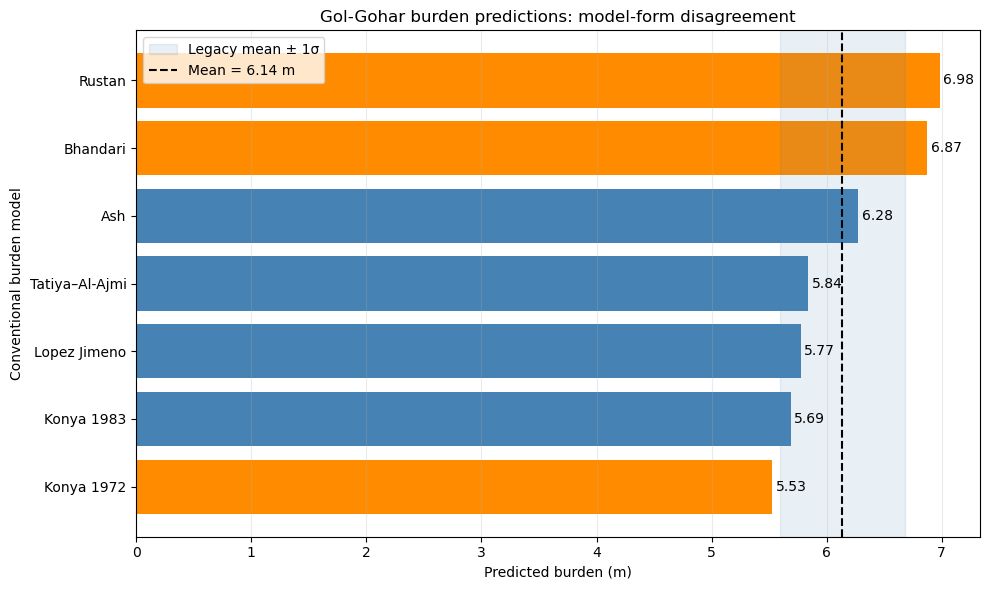

In [14]:
plot_table = conventional_burden_comparison.sort_values(
    "burden_m"
).copy()

plot_colors = np.where(
    plot_table["within_legacy_1sigma"],
    "steelblue",
    "darkorange",
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    plot_table["model_name"],
    plot_table["burden_m"],
    color=plot_colors,
)

ax.axvspan(
    legacy_1sigma_lower,
    legacy_1sigma_upper,
    color="steelblue",
    alpha=0.12,
    label="Legacy mean ± 1σ",
)

ax.axvline(
    burden_mean_m,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Mean = {burden_mean_m:.2f} m",
)

for bar, value in zip(
    bars,
    plot_table["burden_m"],
):
    ax.text(
        value + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
    )

ax.set_xlabel("Predicted burden (m)")
ax.set_ylabel("Conventional burden model")
ax.set_title(
    "Gol-Gohar burden predictions: model-form disagreement"
)
ax.legend()
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

## Step 24.13 — Reproducible legacy burden-screening rule

This function reproduces the historical BlastDesign procedure of retaining
burden estimates within one population standard deviation of the seven-model
mean and averaging the retained values.

The rule is preserved for legacy reproducibility. It is an engineering
screening heuristic, not a statistical confidence interval or proof that
excluded models are invalid.

In [15]:
def legacy_one_sigma_burden_selection(results):
    """
    Reproduce the legacy BlastDesign one-standard-deviation
    burden-screening procedure.

    Parameters
    ----------
    results : pandas.DataFrame
        Must contain model_id, model_name, and burden_m.

    Returns
    -------
    screened_results : pandas.DataFrame
        Original results with screening information.

    summary : pandas.DataFrame
        Numerical summary of the legacy procedure.
    """

    required_columns = {"model_id", "model_name", "burden_m"}
    missing_columns = required_columns - set(results.columns)

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {sorted(missing_columns)}"
        )

    screened_results = results.copy()

    if screened_results["model_id"].duplicated().any():
        raise ValueError("Every model_id must be unique.")

    screened_results["burden_m"] = pd.to_numeric(
        screened_results["burden_m"],
        errors="raise",
    )

    burden_values = screened_results["burden_m"].to_numpy(
        dtype=float
    )

    if len(burden_values) < 2:
        raise ValueError("At least two burden estimates are required.")

    if not np.isfinite(burden_values).all():
        raise ValueError("All burden estimates must be finite.")

    if (burden_values <= 0).any():
        raise ValueError("All burden estimates must be greater than zero.")

    raw_mean_m = float(np.mean(burden_values))
    population_sd_m = float(np.std(burden_values, ddof=0))

    lower_limit_m = raw_mean_m - population_sd_m
    upper_limit_m = raw_mean_m + population_sd_m

    screened_results["deviation_from_mean_m"] = (
        screened_results["burden_m"] - raw_mean_m
    )

    screened_results["within_legacy_1sigma"] = (
        screened_results["burden_m"].between(
            lower_limit_m,
            upper_limit_m,
            inclusive="both",
        )
    )

    screened_results["legacy_decision"] = np.where(
        screened_results["within_legacy_1sigma"],
        "Retained",
        "Excluded",
    )

    retained_mask = screened_results["within_legacy_1sigma"]
    retained_values = screened_results.loc[
        retained_mask,
        "burden_m",
    ]

    selected_burden_m = float(retained_values.mean())

    summary = pd.DataFrame(
        {
            "number_of_models": [len(burden_values)],
            "raw_mean_m": [raw_mean_m],
            "population_sd_m": [population_sd_m],
            "lower_1sigma_m": [lower_limit_m],
            "upper_1sigma_m": [upper_limit_m],
            "number_retained": [int(retained_mask.sum())],
            "number_excluded": [int((~retained_mask).sum())],
            "legacy_selected_burden_m": [selected_burden_m],
        }
    )

    return screened_results, summary

In [16]:
legacy_screened_results, legacy_burden_summary = (
    legacy_one_sigma_burden_selection(
        burden_audit_results
    )
)

display(
    legacy_screened_results[
        [
            "model_id",
            "model_name",
            "burden_m",
            "deviation_from_mean_m",
            "legacy_decision",
        ]
    ].round(6)
)

display(legacy_burden_summary.round(6))

,model_id,model_name,burden_m,deviation_from_mean_m,legacy_decision
0,CONV_ASH,Ash,6.275000,0.137629,Retained
1,CONV_BHANDARI,Bhandari,6.874000,0.736629,Excluded
2,CONV_JIMENO,Lopez Jimeno,5.773000,-0.364371,Retained
3,CONV_KONYA_1972,Konya 1972,5.527324,-0.610048,Excluded
4,CONV_KONYA_1983,Konya 1983,5.689716,-0.447655,Retained
5,CONV_RUSTAN,Rustan,6.983189,0.845817,Excluded
6,CONV_TATIYA,Tatiya–Al-Ajmi,5.839370,-0.298001,Retained


,number_of_models,raw_mean_m,population_sd_m,lower_1sigma_m,upper_1sigma_m,number_retained,number_excluded,legacy_selected_burden_m
0,7,6.137371,0.54394,5.593431,6.681311,4,3,5.894272


In [17]:
excluded_model_ids = set(
    legacy_screened_results.loc[
        legacy_screened_results["legacy_decision"] == "Excluded",
        "model_id",
    ]
)

expected_excluded_ids = {
    "CONV_BHANDARI",
    "CONV_KONYA_1972",
    "CONV_RUSTAN",
}

assert excluded_model_ids == expected_excluded_ids

assert (
    legacy_burden_summary.loc[0, "number_retained"]
    == 4
)

assert np.isclose(
    legacy_burden_summary.loc[
        0,
        "population_sd_m",
    ],
    0.5439399623579156,
)

assert np.isclose(
    legacy_burden_summary.loc[
        0,
        "legacy_selected_burden_m",
    ],
    5.894271561784897,
)

print("Step 24.13 legacy burden-selection tests passed.")

Step 24.13 legacy burden-selection tests passed.


## Step 24.14 — Leave-one-model-out sensitivity analysis

Each conventional burden model is removed once, and the legacy one-standard-
deviation screening procedure is recalculated.

This analysis measures the sensitivity of the legacy result to individual
models. It does not constitute field validation or a statistical confidence
interval.

In [18]:
def leave_one_model_out_legacy_analysis(results):
    """
    Recalculate the legacy burden selection after removing
    each model individually.
    """

    if len(results) < 3:
        raise ValueError(
            "At least three models are required for this analysis."
        )

    _, baseline_summary = legacy_one_sigma_burden_selection(
        results
    )

    baseline_burden_m = float(
        baseline_summary.loc[
            0,
            "legacy_selected_burden_m",
        ]
    )

    records = []

    for model in results[
        ["model_id", "model_name"]
    ].itertuples(index=False):

        reduced_results = results.loc[
            results["model_id"] != model.model_id
        ].copy()

        reduced_screening, reduced_summary = (
            legacy_one_sigma_burden_selection(
                reduced_results
            )
        )

        selected_burden_m = float(
            reduced_summary.loc[
                0,
                "legacy_selected_burden_m",
            ]
        )

        retained_ids = reduced_screening.loc[
            reduced_screening["legacy_decision"] == "Retained",
            "model_id",
        ].tolist()

        excluded_ids = reduced_screening.loc[
            reduced_screening["legacy_decision"] == "Excluded",
            "model_id",
        ].tolist()

        records.append(
            {
                "removed_model_id": model.model_id,
                "removed_model_name": model.model_name,
                "raw_mean_m": reduced_summary.loc[
                    0,
                    "raw_mean_m",
                ],
                "population_sd_m": reduced_summary.loc[
                    0,
                    "population_sd_m",
                ],
                "number_retained": reduced_summary.loc[
                    0,
                    "number_retained",
                ],
                "selected_burden_m": selected_burden_m,
                "change_from_baseline_m": (
                    selected_burden_m - baseline_burden_m
                ),
                "absolute_change_m": abs(
                    selected_burden_m - baseline_burden_m
                ),
                "retained_model_ids": "; ".join(retained_ids),
                "excluded_model_ids": "; ".join(excluded_ids),
            }
        )

    return pd.DataFrame(records)

In [19]:
leave_one_out_results = (
    leave_one_model_out_legacy_analysis(
        burden_audit_results
    )
)

display(
    leave_one_out_results[
        [
            "removed_model_name",
            "number_retained",
            "selected_burden_m",
            "change_from_baseline_m",
            "absolute_change_m",
        ]
    ]
    .sort_values(
        "absolute_change_m",
        ascending=False,
    )
    .round(6)
)

,removed_model_name,number_retained,selected_burden_m,change_from_baseline_m,absolute_change_m
0,Ash,3,5.767362,-0.126909,0.126909
1,Bhandari,5,5.820882,-0.073390,0.073390
3,Konya 1972,3,5.962457,0.068185,0.068185
4,Konya 1983,3,5.962457,0.068185,0.068185
2,Lopez Jimeno,3,5.934695,0.040424,0.040424
6,Tatiya–Al-Ajmi,3,5.912572,0.018301,0.018301
5,Rustan,4,5.894272,0.000000,0.000000


In [20]:
minimum_lomo_burden_m = (
    leave_one_out_results["selected_burden_m"].min()
)

maximum_lomo_burden_m = (
    leave_one_out_results["selected_burden_m"].max()
)

lomo_range_m = (
    maximum_lomo_burden_m
    - minimum_lomo_burden_m
)

assert len(leave_one_out_results) == 7

assert np.isclose(
    minimum_lomo_burden_m,
    5.7673620823798615,
)

assert np.isclose(
    maximum_lomo_burden_m,
    5.962456666666665,
)

assert np.isclose(
    lomo_range_m,
    0.19509458428680393,
)

rustan_change_m = leave_one_out_results.loc[
    leave_one_out_results["removed_model_id"]
    == "CONV_RUSTAN",
    "change_from_baseline_m",
].iloc[0]

assert np.isclose(rustan_change_m, 0.0)

print("Step 24.14 leave-one-model-out tests passed.")
print(
    f"Leave-one-model-out range: "
    f"{minimum_lomo_burden_m:.3f}–"
    f"{maximum_lomo_burden_m:.3f} m"
)
print(f"Total sensitivity span: {lomo_range_m:.3f} m")

Step 24.14 leave-one-model-out tests passed.
Leave-one-model-out range: 5.767–5.962 m
Total sensitivity span: 0.195 m


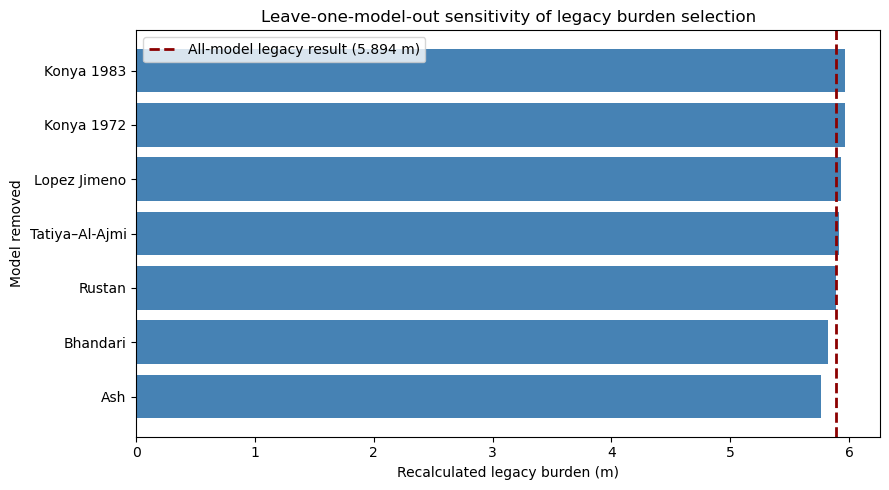

In [21]:
plot_data = leave_one_out_results.sort_values(
    "selected_burden_m"
)

baseline_burden_m = float(
    legacy_burden_summary.loc[
        0,
        "legacy_selected_burden_m",
    ]
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    plot_data["removed_model_name"],
    plot_data["selected_burden_m"],
    color="steelblue",
)

ax.axvline(
    baseline_burden_m,
    color="darkred",
    linestyle="--",
    linewidth=2,
    label=(
        f"All-model legacy result "
        f"({baseline_burden_m:.3f} m)"
    ),
)

ax.set_xlabel("Recalculated legacy burden (m)")
ax.set_ylabel("Model removed")
ax.set_title(
    "Leave-one-model-out sensitivity of legacy burden selection"
)
ax.legend()

plt.tight_layout()
plt.show()

In [22]:
leave_one_out_results.to_csv(
    processed_dir
    / "burden_leave_one_out_step_24_14.csv",
    index=False,
)

print("Step 24.14 results saved.")

Step 24.14 results saved.


## Step 24.15 — Aggregation-method sensitivity

The seven deterministic burden predictions are summarized using several
aggregation rules. Differences among these estimates represent methodological
sensitivity, not statistical confidence or calibrated predictive uncertainty.

No aggregation method is considered field-validated at this stage.

In [23]:
def compare_burden_aggregation_methods(results):
    """
    Compare alternative descriptive aggregation methods for
    conventional burden predictions.
    """

    screened_results, legacy_summary = (
        legacy_one_sigma_burden_selection(results)
    )

    burden_values = results["burden_m"].to_numpy(
        dtype=float
    )

    if len(burden_values) < 3:
        raise ValueError(
            "At least three burden estimates are required."
        )

    sorted_values = np.sort(burden_values)

    arithmetic_mean_m = float(
        np.mean(burden_values)
    )

    median_m = float(
        np.median(burden_values)
    )

    symmetric_trimmed_mean_m = float(
        np.mean(sorted_values[1:-1])
    )

    legacy_selected_m = float(
        legacy_summary.loc[
            0,
            "legacy_selected_burden_m",
        ]
    )

    comparison = pd.DataFrame(
        [
            {
                "method_id": "ARITHMETIC_MEAN",
                "method_name": "Arithmetic mean",
                "burden_estimate_m": arithmetic_mean_m,
                "aggregation_rule": "Mean of all seven models",
            },
            {
                "method_id": "MEDIAN",
                "method_name": "Median",
                "burden_estimate_m": median_m,
                "aggregation_rule": "Middle ordered prediction",
            },
            {
                "method_id": "SYMMETRIC_TRIMMED_MEAN",
                "method_name": "Symmetric trimmed mean",
                "burden_estimate_m": symmetric_trimmed_mean_m,
                "aggregation_rule": (
                    "Remove one lowest and one highest value"
                ),
            },
            {
                "method_id": "LEGACY_ONE_SIGMA",
                "method_name": "Legacy one-sigma screening",
                "burden_estimate_m": legacy_selected_m,
                "aggregation_rule": (
                    "Average predictions inside mean ± 1σ"
                ),
            },
        ]
    )

    comparison["difference_from_legacy_m"] = (
        comparison["burden_estimate_m"]
        - legacy_selected_m
    )

    comparison["difference_from_legacy_percent"] = (
        comparison["difference_from_legacy_m"]
        / legacy_selected_m
        * 100.0
    )

    q1_m, q3_m = np.percentile(
        burden_values,
        [25, 75],
    )

    median_absolute_deviation_m = float(
        np.median(
            np.abs(burden_values - median_m)
        )
    )

    spread_summary = pd.DataFrame(
        {
            "minimum_method_estimate_m": [
                comparison["burden_estimate_m"].min()
            ],
            "maximum_method_estimate_m": [
                comparison["burden_estimate_m"].max()
            ],
            "method_sensitivity_span_m": [
                comparison["burden_estimate_m"].max()
                - comparison["burden_estimate_m"].min()
            ],
            "q1_model_prediction_m": [q1_m],
            "q3_model_prediction_m": [q3_m],
            "interquartile_range_m": [q3_m - q1_m],
            "median_absolute_deviation_m": [
                median_absolute_deviation_m
            ],
        }
    )

    return comparison, spread_summary

In [24]:
aggregation_comparison, robust_spread_summary = (
    compare_burden_aggregation_methods(
        burden_audit_results
    )
)

display(
    aggregation_comparison[
        [
            "method_name",
            "burden_estimate_m",
            "difference_from_legacy_m",
            "difference_from_legacy_percent",
        ]
    ]
    .sort_values("burden_estimate_m")
    .round(6)
)

display(robust_spread_summary.round(6))

,method_name,burden_estimate_m,difference_from_legacy_m,difference_from_legacy_percent
1,Median,5.839370,-0.054902,-0.931439
3,Legacy one-sigma screening,5.894272,0.000000,0.000000
2,Symmetric trimmed mean,6.090217,0.195946,3.324341
0,Arithmetic mean,6.137371,0.243100,4.124337


,minimum_method_estimate_m,maximum_method_estimate_m,method_sensitivity_span_m,q1_model_prediction_m,q3_model_prediction_m,interquartile_range_m,median_absolute_deviation_m
0,5.83937,6.137371,0.298001,5.731358,6.5745,0.843142,0.312046


In [25]:
aggregation_values = (
    aggregation_comparison
    .set_index("method_id")["burden_estimate_m"]
)

assert np.isclose(
    aggregation_values["ARITHMETIC_MEAN"],
    6.137371203249507,
)

assert np.isclose(
    aggregation_values["MEDIAN"],
    5.839369999999999,
)

assert np.isclose(
    aggregation_values["SYMMETRIC_TRIMMED_MEAN"],
    6.0902172494279165,
)

assert np.isclose(
    aggregation_values["LEGACY_ONE_SIGMA"],
    5.894271561784897,
)

assert np.isclose(
    robust_spread_summary.loc[
        0,
        "method_sensitivity_span_m",
    ],
    0.2980012032495081,
)

assert np.isclose(
    robust_spread_summary.loc[
        0,
        "median_absolute_deviation_m",
    ],
    0.3120463836574423,
)

print("Step 24.15 aggregation-method tests passed.")

Step 24.15 aggregation-method tests passed.


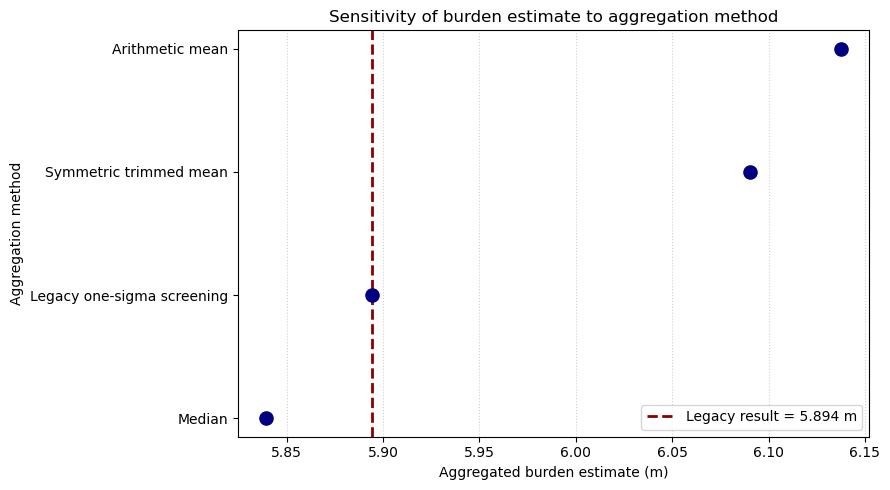

In [26]:
plot_data = aggregation_comparison.sort_values(
    "burden_estimate_m"
)

legacy_value_m = aggregation_values[
    "LEGACY_ONE_SIGMA"
]

fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(
    plot_data["burden_estimate_m"],
    plot_data["method_name"],
    color="navy",
    s=90,
    zorder=3,
)

ax.axvline(
    legacy_value_m,
    color="darkred",
    linestyle="--",
    linewidth=2,
    label=f"Legacy result = {legacy_value_m:.3f} m",
)

ax.grid(
    axis="x",
    linestyle=":",
    alpha=0.6,
)

ax.set_xlabel("Aggregated burden estimate (m)")
ax.set_ylabel("Aggregation method")
ax.set_title(
    "Sensitivity of burden estimate to aggregation method"
)
ax.legend()

plt.tight_layout()
plt.show()

In [27]:
aggregation_comparison.to_csv(
    processed_dir
    / "burden_aggregation_comparison_step_24_15.csv",
    index=False,
)

robust_spread_summary.to_csv(
    processed_dir
    / "burden_robust_spread_step_24_15.csv",
    index=False,
)

print("Step 24.15 results saved.")

Step 24.15 results saved.


## Step 24.16 — Applicability and evidence ledger

Numerical reproduction does not demonstrate predictive validity. Each burden
model must also be assessed against its documented diameter range, rock-strength
branch, explosive type, material properties, calibration domain and independent
validation evidence.

The classifications below refer only to currently audited documentation. An
“AUDITED_BRANCH_MATCH” classification is not equivalent to independent field
validation.

In [28]:
gole_gohar_benchmark_case = pd.DataFrame(
    [
        {
            "case_id": "GOLE_GOHAR_THESIS_BENCHMARK",
            "hole_diameter_mm": 251.0,
            "ucs_mpa": 85.0,
            "explosive_type": "ANFO",
            "explosive_density_g_cm3": 0.85,
            "rock_density_g_cm3": 4.37,
            "data_status": (
                "Legacy thesis benchmark; not an "
                "independent validation dataset"
            ),
        }
    ]
)

display(gole_gohar_benchmark_case.T)

,0
case_id,GOLE_GOHAR_THESIS_BENCHMARK
hole_diameter_mm,251.0
ucs_mpa,85.0
explosive_type,ANFO
explosive_density_g_cm3,0.85
rock_density_g_cm3,4.37
data_status,Legacy thesis benchmark; not an independent va...


In [29]:
burden_applicability_ledger = pd.DataFrame(
    [
        {
            "model_id": "CONV_ASH",
            "audit_domain_status": "PARTIAL_BRANCH_MATCH",
            "known_conditions_checked": (
                "Burden ratio 25 is inside implemented range 20–40"
            ),
            "unresolved_evidence": (
                "Primary calibration domain and independent "
                "field validation remain unresolved"
            ),
            "independent_validation_status": "Not established",
        },
        {
            "model_id": "CONV_BHANDARI",
            "audit_domain_status": "DOMAIN_UNRESOLVED",
            "known_conditions_checked": (
                "Positive 251 mm hole diameter"
            ),
            "unresolved_evidence": (
                "Diameter, geology and calibration limits "
                "are not yet verified from a primary source"
            ),
            "independent_validation_status": "Not established",
        },
        {
            "model_id": "CONV_JIMENO",
            "audit_domain_status": "AUDITED_BRANCH_MATCH",
            "known_conditions_checked": (
                "251 mm is above 180 mm; ANFO large-hole "
                "branch; UCS 85 MPa"
            ),
            "unresolved_evidence": (
                "Independent predictive validation remains unresolved"
            ),
            "independent_validation_status": "Not established",
        },
        {
            "model_id": "CONV_KONYA_1972",
            "audit_domain_status": "DOMAIN_UNRESOLVED",
            "known_conditions_checked": (
                "Positive diameter and positive explosive "
                "and rock densities"
            ),
            "unresolved_evidence": (
                "Original calibration and applicability "
                "limits remain unresolved"
            ),
            "independent_validation_status": "Not established",
        },
        {
            "model_id": "CONV_KONYA_1983",
            "audit_domain_status": "DOMAIN_UNRESOLVED",
            "known_conditions_checked": (
                "Positive diameter and positive explosive "
                "and rock densities"
            ),
            "unresolved_evidence": (
                "Original calibration and applicability "
                "limits remain unresolved"
            ),
            "independent_validation_status": "Not established",
        },
        {
            "model_id": "CONV_RUSTAN",
            "audit_domain_status": "AUDITED_BRANCH_MATCH",
            "known_conditions_checked": (
                "251 mm is inside documented 89–311 mm range"
            ),
            "unresolved_evidence": (
                "Independent predictive validation remains unresolved"
            ),
            "independent_validation_status": "Not established",
        },
        {
            "model_id": "CONV_TATIYA",
            "audit_domain_status": "PARTIAL_BRANCH_MATCH",
            "known_conditions_checked": (
                "ANFO coefficients; UCS 85 MPa is inside "
                "the 55–110 MPa branch"
            ),
            "unresolved_evidence": (
                "Diameter and broader calibration-domain "
                "limits remain unresolved"
            ),
            "independent_validation_status": "Not established",
        },
    ]
)

display(burden_applicability_ledger)

,model_id,audit_domain_status,known_conditions_checked,unresolved_evidence,independent_validation_status
0,CONV_ASH,PARTIAL_BRANCH_MATCH,Burden ratio 25 is inside implemented range 20–40,Primary calibration domain and independent fie...,Not established
1,CONV_BHANDARI,DOMAIN_UNRESOLVED,Positive 251 mm hole diameter,"Diameter, geology and calibration limits are n...",Not established
2,CONV_JIMENO,AUDITED_BRANCH_MATCH,251 mm is above 180 mm; ANFO large-hole branch...,Independent predictive validation remains unre...,Not established
3,CONV_KONYA_1972,DOMAIN_UNRESOLVED,Positive diameter and positive explosive and r...,Original calibration and applicability limits ...,Not established
4,CONV_KONYA_1983,DOMAIN_UNRESOLVED,Positive diameter and positive explosive and r...,Original calibration and applicability limits ...,Not established
5,CONV_RUSTAN,AUDITED_BRANCH_MATCH,251 mm is inside documented 89–311 mm range,Independent predictive validation remains unre...,Not established
6,CONV_TATIYA,PARTIAL_BRANCH_MATCH,ANFO coefficients; UCS 85 MPa is inside the 55...,Diameter and broader calibration-domain limits...,Not established


In [30]:
burden_applicability_review = (
    burden_audit_results[
        [
            "model_id",
            "model_name",
            "burden_m",
        ]
    ]
    .merge(
        burden_applicability_ledger,
        on="model_id",
        how="left",
        validate="one_to_one",
    )
)

display(
    burden_applicability_review[
        [
            "model_name",
            "burden_m",
            "audit_domain_status",
            "known_conditions_checked",
            "unresolved_evidence",
        ]
    ]
)

,model_name,burden_m,audit_domain_status,known_conditions_checked,unresolved_evidence
0,Ash,6.275000,PARTIAL_BRANCH_MATCH,Burden ratio 25 is inside implemented range 20–40,Primary calibration domain and independent fie...
1,Bhandari,6.874000,DOMAIN_UNRESOLVED,Positive 251 mm hole diameter,"Diameter, geology and calibration limits are n..."
2,Lopez Jimeno,5.773000,AUDITED_BRANCH_MATCH,251 mm is above 180 mm; ANFO large-hole branch...,Independent predictive validation remains unre...
3,Konya 1972,5.527324,DOMAIN_UNRESOLVED,Positive diameter and positive explosive and r...,Original calibration and applicability limits ...
4,Konya 1983,5.689716,DOMAIN_UNRESOLVED,Positive diameter and positive explosive and r...,Original calibration and applicability limits ...
5,Rustan,6.983189,AUDITED_BRANCH_MATCH,251 mm is inside documented 89–311 mm range,Independent predictive validation remains unre...
6,Tatiya–Al-Ajmi,5.839370,PARTIAL_BRANCH_MATCH,ANFO coefficients; UCS 85 MPa is inside the 55...,Diameter and broader calibration-domain limits...


In [31]:
expected_model_ids = set(
    burden_audit_results["model_id"]
)

ledger_model_ids = set(
    burden_applicability_ledger["model_id"]
)

assert ledger_model_ids == expected_model_ids

assert burden_applicability_ledger[
    "model_id"
].is_unique

assert not burden_applicability_review[
    "audit_domain_status"
].isna().any()

status_counts = (
    burden_applicability_ledger[
        "audit_domain_status"
    ]
    .value_counts()
    .to_dict()
)

assert status_counts == {
    "DOMAIN_UNRESOLVED": 3,
    "AUDITED_BRANCH_MATCH": 2,
    "PARTIAL_BRANCH_MATCH": 2,
}

assert (
    burden_applicability_ledger[
        "independent_validation_status"
    ]
    == "Not established"
).all()

print("Step 24.16 applicability-ledger tests passed.")

Step 24.16 applicability-ledger tests passed.


In [32]:
burden_applicability_review.to_csv(
    processed_dir
    / "burden_applicability_ledger_step_24_16.csv",
    index=False,
)

print("Step 24.16 applicability ledger saved.")

Step 24.16 applicability ledger saved.


### Step 24.16 interpretation

All seven models reproduce the legacy benchmark numerically, but they do not
currently possess equal applicability evidence. López Jimeno and Rustan match
their presently documented branches or ranges. Ash and Tatiya–Al-Ajmi have
partial domain support, while the audited domains of Bhandari and the two Konya
relationships remain unresolved.

None of the seven models currently has independent field validation within this
project. Consequently, this ledger must not be interpreted as a ranking of
predictive accuracy or as a modern design recommendation.

## Step 24.17 — Evidence-aware burden recommendation

Load and verify the Step 24.16 applicability ledger before defining
transparent model-inclusion tiers. This prevents unverified or
domain-unresolved equations from silently influencing the recommendation.

In [33]:
from pathlib import Path
import pandas as pd

cwd = Path.cwd().resolve()

project_root = next(
    (
        path
        for path in (cwd, *cwd.parents)
        if (path / ".git").exists()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        f"Could not identify the Git project root from: {cwd}"
    )

ledger_path = (
    project_root
    / "data"
    / "processed"
    / "burden_applicability_ledger_step_24_16.csv"
)

if not ledger_path.exists():
    alternatives = sorted(
        project_root.rglob("*step_24_16*.csv")
    )

    raise FileNotFoundError(
        f"Expected ledger not found at: {ledger_path}\n"
        f"Other Step 24.16 CSV files found: {alternatives}"
    )

applicability_ledger = pd.read_csv(ledger_path)

print(f"Project root: {project_root}")
print(f"Loaded: {ledger_path}")
print(f"Shape: {applicability_ledger.shape}")
print("\nColumns:")

for column in applicability_ledger.columns:
    print(f"- {column}")

display(applicability_ledger)

Project root: F:\Projects\BlastDesign-AI
Loaded: F:\Projects\BlastDesign-AI\data\processed\burden_applicability_ledger_step_24_16.csv
Shape: (7, 7)

Columns:
- model_id
- model_name
- burden_m
- audit_domain_status
- known_conditions_checked
- unresolved_evidence
- independent_validation_status


,model_id,model_name,burden_m,audit_domain_status,known_conditions_checked,unresolved_evidence,independent_validation_status
0,CONV_ASH,Ash,6.275000,PARTIAL_BRANCH_MATCH,Burden ratio 25 is inside implemented range 20–40,Primary calibration domain and independent fie...,Not established
1,CONV_BHANDARI,Bhandari,6.874000,DOMAIN_UNRESOLVED,Positive 251 mm hole diameter,"Diameter, geology and calibration limits are n...",Not established
2,CONV_JIMENO,Lopez Jimeno,5.773000,AUDITED_BRANCH_MATCH,251 mm is above 180 mm; ANFO large-hole branch...,Independent predictive validation remains unre...,Not established
3,CONV_KONYA_1972,Konya 1972,5.527324,DOMAIN_UNRESOLVED,Positive diameter and positive explosive and r...,Original calibration and applicability limits ...,Not established
4,CONV_KONYA_1983,Konya 1983,5.689716,DOMAIN_UNRESOLVED,Positive diameter and positive explosive and r...,Original calibration and applicability limits ...,Not established
5,CONV_RUSTAN,Rustan,6.983189,AUDITED_BRANCH_MATCH,251 mm is inside documented 89–311 mm range,Independent predictive validation remains unre...,Not established
6,CONV_TATIYA,Tatiya–Al-Ajmi,5.839370,PARTIAL_BRANCH_MATCH,ANFO coefficients; UCS 85 MPa is inside the 55...,Diameter and broader calibration-domain limits...,Not established


### Step 24.17B — Evidence tiers and provisional screening scenarios

The implementation audit is converted into three evidence tiers:

- Tier A: implemented equation branch matches the documented benchmark conditions.
- Tier B: only a partial branch/domain match has been established.
- Tier C: the model's applicability domain remains unresolved.

These tiers support methodological sensitivity analysis. They do not constitute
independent field validation or a practitioner-ready burden recommendation.

In [34]:
import numpy as np
import pandas as pd

required_columns = {
    "model_id",
    "model_name",
    "burden_m",
    "audit_domain_status",
    "independent_validation_status",
}

missing_columns = required_columns.difference(
    applicability_ledger.columns
)

if missing_columns:
    raise ValueError(
        f"Missing required ledger columns: {sorted(missing_columns)}"
    )

audit_status_to_tier = {
    "AUDITED_BRANCH_MATCH": "A",
    "PARTIAL_BRANCH_MATCH": "B",
    "DOMAIN_UNRESOLVED": "C",
}

tier_descriptions = {
    "A": "Audited implementation-branch match",
    "B": "Partial implementation/domain match",
    "C": "Applicability domain unresolved",
}

observed_statuses = set(
    applicability_ledger["audit_domain_status"].dropna()
)

unknown_statuses = observed_statuses.difference(
    audit_status_to_tier
)

if unknown_statuses:
    raise ValueError(
        f"Unexpected audit-domain statuses: {sorted(unknown_statuses)}"
    )

evidence_tiers = applicability_ledger.copy()

evidence_tiers["evidence_tier"] = (
    evidence_tiers["audit_domain_status"]
    .map(audit_status_to_tier)
)

evidence_tiers["tier_description"] = (
    evidence_tiers["evidence_tier"]
    .map(tier_descriptions)
)

evidence_tiers["independent_validation_established"] = (
    evidence_tiers["independent_validation_status"]
    .astype(str)
    .str.strip()
    .str.casefold()
    .eq("established")
)

scenario_definitions = [
    (
        "ALL_LEGACY_COMPARATOR",
        ["A", "B", "C"],
        "Unfiltered seven-model legacy comparator",
    ),
    (
        "AUDITED_PLUS_PARTIAL",
        ["A", "B"],
        "Models with audited or partial branch matches",
    ),
    (
        "AUDITED_ONLY",
        ["A"],
        "Models with audited implementation-branch matches",
    ),
]


def summarize_screening_scenario(
    tier_table,
    scenario_id,
    included_tiers,
    scenario_description,
):
    subset = tier_table[
        tier_table["evidence_tier"].isin(included_tiers)
    ].copy()

    burden_values = subset["burden_m"].astype(float)

    return {
        "scenario_id": scenario_id,
        "scenario_description": scenario_description,
        "included_tiers": "+".join(included_tiers),
        "model_count": len(subset),
        "model_ids": ", ".join(subset["model_id"]),
        "mean_burden_m": burden_values.mean(),
        "median_burden_m": burden_values.median(),
        "population_sd_m": burden_values.std(ddof=0),
        "minimum_burden_m": burden_values.min(),
        "maximum_burden_m": burden_values.max(),
        "range_m": burden_values.max() - burden_values.min(),
        "independently_validated_model_count": int(
            subset["independent_validation_established"].sum()
        ),
    }


screening_scenarios = pd.DataFrame(
    [
        summarize_screening_scenario(
            evidence_tiers,
            scenario_id,
            included_tiers,
            scenario_description,
        )
        for (
            scenario_id,
            included_tiers,
            scenario_description,
        ) in scenario_definitions
    ]
)

tier_counts = (
    evidence_tiers["evidence_tier"]
    .value_counts()
    .sort_index()
    .to_dict()
)

assert tier_counts == {"A": 2, "B": 2, "C": 3}
assert evidence_tiers[
    "independent_validation_established"
].sum() == 0

assert screening_scenarios.set_index("scenario_id").loc[
    "ALL_LEGACY_COMPARATOR", "model_count"
] == 7

assert screening_scenarios.set_index("scenario_id").loc[
    "AUDITED_PLUS_PARTIAL", "model_count"
] == 4

assert screening_scenarios.set_index("scenario_id").loc[
    "AUDITED_ONLY", "model_count"
] == 2

output_directory = project_root / "data" / "processed"
output_directory.mkdir(parents=True, exist_ok=True)

tier_output_path = (
    output_directory
    / "burden_evidence_tiers_step_24_17.csv"
)

scenario_output_path = (
    output_directory
    / "burden_screening_scenarios_step_24_17.csv"
)

evidence_tiers.to_csv(tier_output_path, index=False)
screening_scenarios.to_csv(scenario_output_path, index=False)

print("Evidence-tier counts:", tier_counts)
print("\nScreening scenarios:")
display(
    screening_scenarios[
        [
            "scenario_id",
            "model_count",
            "mean_burden_m",
            "median_burden_m",
            "population_sd_m",
            "minimum_burden_m",
            "maximum_burden_m",
            "range_m",
            "independently_validated_model_count",
        ]
    ].round(6)
)

print(
    "\nInterpretation: these are provisional screening "
    "scenarios, not validated design recommendations."
)
print(f"\nSaved: {tier_output_path}")
print(f"Saved: {scenario_output_path}")

Evidence-tier counts: {'A': 2, 'B': 2, 'C': 3}

Screening scenarios:


,scenario_id,model_count,mean_burden_m,median_burden_m,population_sd_m,minimum_burden_m,maximum_burden_m,range_m,independently_validated_model_count
0,ALL_LEGACY_COMPARATOR,7,6.137371,5.839370,0.543940,5.527324,6.983189,1.455865,0
1,AUDITED_PLUS_PARTIAL,4,6.217640,6.057185,0.482221,5.773000,6.983189,1.210189,0
2,AUDITED_ONLY,2,6.378094,6.378094,0.605094,5.773000,6.983189,1.210189,0



Interpretation: these are provisional screening scenarios, not validated design recommendations.

Saved: F:\Projects\BlastDesign-AI\data\processed\burden_evidence_tiers_step_24_17.csv
Saved: F:\Projects\BlastDesign-AI\data\processed\burden_screening_scenarios_step_24_17.csv


## Step 24.18 — Structural model-form uncertainty

Differences among empirical burden equations represent structural and
model-selection uncertainty, not random sampling error. Therefore, their
spread is summarized deterministically without assigning confidence levels,
probabilities, or statistical significance.

Each audit-screened scenario is compared with the complete seven-model
legacy comparator. Independent site validation remains a separate
requirement.

In [35]:
required_scenario_columns = {
    "scenario_id",
    "model_count",
    "mean_burden_m",
    "median_burden_m",
    "population_sd_m",
    "minimum_burden_m",
    "maximum_burden_m",
    "range_m",
    "independently_validated_model_count",
}

missing_scenario_columns = required_scenario_columns.difference(
    screening_scenarios.columns
)

if missing_scenario_columns:
    raise ValueError(
        "Missing screening-scenario columns: "
        f"{sorted(missing_scenario_columns)}"
    )

structural_uncertainty = screening_scenarios.copy()

legacy_row = structural_uncertainty[
    structural_uncertainty["scenario_id"]
    == "ALL_LEGACY_COMPARATOR"
]

if len(legacy_row) != 1:
    raise ValueError(
        "Exactly one ALL_LEGACY_COMPARATOR row was expected."
    )

legacy_mean = float(
    legacy_row.iloc[0]["mean_burden_m"]
)

legacy_median = float(
    legacy_row.iloc[0]["median_burden_m"]
)

structural_uncertainty["mean_shift_from_legacy_m"] = (
    structural_uncertainty["mean_burden_m"]
    - legacy_mean
)

structural_uncertainty["mean_shift_from_legacy_percent"] = (
    structural_uncertainty["mean_shift_from_legacy_m"]
    / legacy_mean
    * 100.0
)

structural_uncertainty["median_shift_from_legacy_m"] = (
    structural_uncertainty["median_burden_m"]
    - legacy_median
)

structural_uncertainty["lower_deviation_from_mean_m"] = (
    structural_uncertainty["mean_burden_m"]
    - structural_uncertainty["minimum_burden_m"]
)

structural_uncertainty["upper_deviation_from_mean_m"] = (
    structural_uncertainty["maximum_burden_m"]
    - structural_uncertainty["mean_burden_m"]
)

structural_uncertainty["relative_range_percent"] = (
    structural_uncertainty["range_m"]
    / structural_uncertainty["mean_burden_m"]
    * 100.0
)

structural_uncertainty["coefficient_of_variation_percent"] = (
    structural_uncertainty["population_sd_m"]
    / structural_uncertainty["mean_burden_m"]
    * 100.0
)

structural_uncertainty["evidence_state"] = np.where(
    structural_uncertainty[
        "independently_validated_model_count"
    ] > 0,
    "INDEPENDENT_VALIDATION_PRESENT",
    "SITE_CALIBRATION_AND_VALIDATION_REQUIRED",
)

assert np.isclose(
    structural_uncertainty.loc[
        structural_uncertainty["scenario_id"]
        == "AUDITED_PLUS_PARTIAL",
        "mean_shift_from_legacy_m",
    ].iloc[0],
    0.080269,
    atol=1e-5,
)

assert np.isclose(
    structural_uncertainty.loc[
        structural_uncertainty["scenario_id"]
        == "AUDITED_ONLY",
        "mean_shift_from_legacy_m",
    ].iloc[0],
    0.240723,
    atol=1e-5,
)

assert (
    structural_uncertainty[
        "independently_validated_model_count"
    ] == 0
).all()

uncertainty_output_path = (
    output_directory
    / "burden_structural_uncertainty_step_24_18.csv"
)

structural_uncertainty.to_csv(
    uncertainty_output_path,
    index=False,
)

display_columns = [
    "scenario_id",
    "model_count",
    "mean_burden_m",
    "median_burden_m",
    "mean_shift_from_legacy_m",
    "mean_shift_from_legacy_percent",
    "lower_deviation_from_mean_m",
    "upper_deviation_from_mean_m",
    "relative_range_percent",
    "coefficient_of_variation_percent",
    "evidence_state",
]

display(
    structural_uncertainty[display_columns].round(6)
)

audited_only_range = structural_uncertainty.loc[
    structural_uncertainty["scenario_id"]
    == "AUDITED_ONLY",
    "range_m",
].iloc[0]

print(
    "\nKey finding: restricting the comparison to audited "
    f"implementation branches still leaves a "
    f"{audited_only_range:.3f} m burden range."
)

print(
    "This is structural disagreement between equations, "
    "not a confidence interval."
)

print(f"\nSaved: {uncertainty_output_path}")

,scenario_id,model_count,mean_burden_m,median_burden_m,mean_shift_from_legacy_m,mean_shift_from_legacy_percent,lower_deviation_from_mean_m,upper_deviation_from_mean_m,relative_range_percent,coefficient_of_variation_percent,evidence_state
0,ALL_LEGACY_COMPARATOR,7,6.137371,5.839370,0.000000,0.000000,0.610048,0.845817,23.721312,8.862752,SITE_CALIBRATION_AND_VALIDATION_REQUIRED
1,AUDITED_PLUS_PARTIAL,4,6.217640,6.057185,0.080268,1.307863,0.444640,0.765549,19.463794,7.755689,SITE_CALIBRATION_AND_VALIDATION_REQUIRED
2,AUDITED_ONLY,2,6.378094,6.378094,0.240723,3.922251,0.605094,0.605094,18.974140,9.487070,SITE_CALIBRATION_AND_VALIDATION_REQUIRED



Key finding: restricting the comparison to audited implementation branches still leaves a 1.210 m burden range.
This is structural disagreement between equations, not a confidence interval.

Saved: F:\Projects\BlastDesign-AI\data\processed\burden_structural_uncertainty_step_24_18.csv


## Step 24.19 — Publication-oriented structural-uncertainty figure

The figure compares mean and median burdens with the complete minimum-to-maximum
model range for each screening scenario. Range bars describe deterministic
model-form variation and must not be interpreted as confidence intervals.

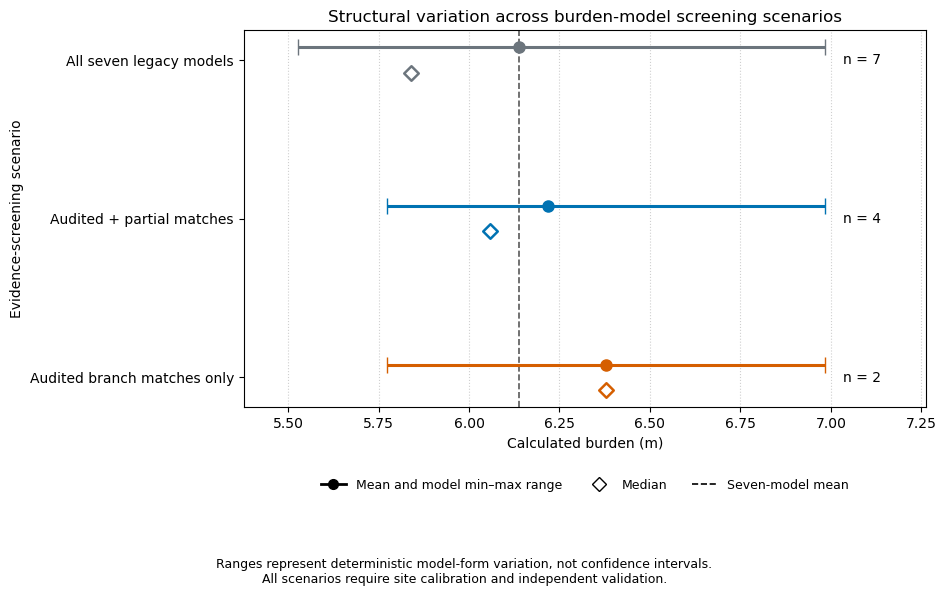

Saved PNG: F:\Projects\BlastDesign-AI\outputs\figures\burden_structural_uncertainty_step_24_19.png
Saved SVG: F:\Projects\BlastDesign-AI\outputs\figures\burden_structural_uncertainty_step_24_19.svg


In [36]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

scenario_order = [
    "ALL_LEGACY_COMPARATOR",
    "AUDITED_PLUS_PARTIAL",
    "AUDITED_ONLY",
]

scenario_labels = {
    "ALL_LEGACY_COMPARATOR": "All seven legacy models",
    "AUDITED_PLUS_PARTIAL": "Audited + partial matches",
    "AUDITED_ONLY": "Audited branch matches only",
}

plot_table = (
    structural_uncertainty
    .set_index("scenario_id")
    .loc[scenario_order]
    .reset_index()
)

y_positions = np.arange(len(plot_table))
range_y_positions = y_positions - 0.08
median_y_positions = y_positions + 0.08

scenario_colors = [
    "#6C757D",
    "#0072B2",
    "#D55E00",
]

fig, ax = plt.subplots(figsize=(10.5, 6.5))

fig.subplots_adjust(
    left=0.29,
    right=0.94,
    top=0.88,
    bottom=0.30,
)

for row_number, row in plot_table.iterrows():
    mean_value = row["mean_burden_m"]

    lower_error = (
        mean_value - row["minimum_burden_m"]
    )

    upper_error = (
        row["maximum_burden_m"] - mean_value
    )

    ax.errorbar(
        mean_value,
        range_y_positions[row_number],
        xerr=np.array([[lower_error], [upper_error]]),
        fmt="o",
        markersize=8,
        linewidth=2.2,
        capsize=6,
        color=scenario_colors[row_number],
        label=None,
        zorder=3,
    )

    ax.scatter(
        row["median_burden_m"],
        median_y_positions[row_number],
        marker="D",
        s=55,
        facecolor="white",
        edgecolor=scenario_colors[row_number],
        linewidth=1.8,
        zorder=4,
    )

    ax.text(
        row["maximum_burden_m"] + 0.05,
        y_positions[row_number],
        f'n = {int(row["model_count"])}',
        va="center",
        fontsize=10,
    )

legacy_mean = plot_table.loc[
    plot_table["scenario_id"]
    == "ALL_LEGACY_COMPARATOR",
    "mean_burden_m",
].iloc[0]

ax.axvline(
    legacy_mean,
    color="black",
    linestyle="--",
    linewidth=1.2,
    alpha=0.65,
)

ax.set_yticks(y_positions)
ax.set_yticklabels(
    [scenario_labels[item] for item in scenario_order]
)

ax.invert_yaxis()

ax.set_xlabel("Calculated burden (m)")
ax.set_ylabel("Evidence-screening scenario")

ax.set_title(
    "Structural variation across burden-model screening scenarios"
)

ax.grid(
    axis="x",
    linestyle=":",
    linewidth=0.8,
    alpha=0.6,
)
overall_minimum = plot_table["minimum_burden_m"].min()
overall_maximum = plot_table["maximum_burden_m"].max()

ax.set_xlim(
    overall_minimum - 0.15,
    overall_maximum + 0.28,
)

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="black",
        linewidth=2,
        markersize=7,
        label="Mean and model min–max range",
    ),
    Line2D(
        [0],
        [0],
        marker="D",
        markerfacecolor="white",
        markeredgecolor="black",
        linestyle="None",
        markersize=7,
        label="Median",
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=1.2,
        label="Seven-model mean",
    ),
]

ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=3,
    frameon=False,
    fontsize=9,
)

fig.text(
    0.5,
    0.025,
    "Ranges represent deterministic model-form variation, not confidence intervals.\n"
    "All scenarios require site calibration and independent validation.",
    ha="center",
    va="bottom",
    fontsize=9,
)

figure_directory = project_root / "outputs" / "figures"
figure_directory.mkdir(parents=True, exist_ok=True)

png_output_path = (
    figure_directory
    / "burden_structural_uncertainty_step_24_19.png"
)

svg_output_path = (
    figure_directory
    / "burden_structural_uncertainty_step_24_19.svg"
)

fig.savefig(
    png_output_path,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    svg_output_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved PNG: {png_output_path}")
print(f"Saved SVG: {svg_output_path}")

## Step 24.20 — Evidence-based burden decision gate

The legacy BlastDesign workflow combined empirical equations into a single
burden estimate. The modernized workflow introduces an explicit decision gate.

Unless site-calibration data and independent validation are available, the
software reports comparative values, structural uncertainty, and evidence
warnings instead of presenting one burden as an operational recommendation.

In [38]:
def assess_burden_decision_readiness(
    tier_table,
    uncertainty_table,
    site_calibration_available,
    minimum_independently_validated_models=1,
):
    required_tier_columns = {
        "model_id",
        "evidence_tier",
        "independent_validation_established",
    }

    missing_tier_columns = required_tier_columns.difference(
        tier_table.columns
    )

    if missing_tier_columns:
        raise ValueError(
            f"Missing evidence-tier columns: "
            f"{sorted(missing_tier_columns)}"
        )

    audited_model_count = int(
        (tier_table["evidence_tier"] == "A").sum()
    )

    partial_model_count = int(
        (tier_table["evidence_tier"] == "B").sum()
    )

    unresolved_model_count = int(
        (tier_table["evidence_tier"] == "C").sum()
    )

    independently_validated_model_count = int(
        tier_table[
            "independent_validation_established"
        ].sum()
    )

    audited_scenario = uncertainty_table[
        uncertainty_table["scenario_id"]
        == "AUDITED_ONLY"
    ]

    if len(audited_scenario) != 1:
        raise ValueError(
            "Exactly one AUDITED_ONLY scenario was expected."
        )

    audited_model_range_m = float(
        audited_scenario.iloc[0]["range_m"]
    )

    blocking_reasons = []
    warning_reasons = []

    if (
        independently_validated_model_count
        < minimum_independently_validated_models
    ):
        blocking_reasons.append(
            "NO_INDEPENDENTLY_VALIDATED_MODEL"
        )

    if not site_calibration_available:
        blocking_reasons.append(
            "NO_SITE_CALIBRATION_DATA"
        )

    if unresolved_model_count > 0:
        warning_reasons.append(
            "UNRESOLVED_MODEL_APPLICABILITY_DOMAINS"
        )

    if audited_model_range_m > 0:
        warning_reasons.append(
            "STRUCTURAL_DISAGREEMENT_REMAINS"
        )

    operational_recommendation_allowed = (
        len(blocking_reasons) == 0
    )

    if operational_recommendation_allowed:
        decision_status = (
            "CANDIDATE_FOR_SITE_SPECIFIC_ENGINEERING_REVIEW"
        )
        software_output_mode = (
            "CALIBRATED_CANDIDATE_WITH_ENGINEERING_REVIEW"
        )
    else:
        decision_status = "RESEARCH_COMPARATOR_ONLY"
        software_output_mode = (
            "COMPARATIVE_RANGE_WITH_EVIDENCE_WARNING"
        )

    return pd.DataFrame(
        [
            {
                "benchmark_hole_diameter_mm": 251.0,
                "benchmark_ucs_mpa": 85.0,
                "benchmark_explosive": "ANFO",
                "audited_model_count": audited_model_count,
                "partial_model_count": partial_model_count,
                "unresolved_model_count": unresolved_model_count,
                "independently_validated_model_count":
                    independently_validated_model_count,
                "minimum_validated_models_required":
                    minimum_independently_validated_models,
                "site_calibration_available":
                    bool(site_calibration_available),
                "audited_model_range_m":
                    audited_model_range_m,
                "operational_recommendation_allowed":
                    operational_recommendation_allowed,
                "decision_status": decision_status,
                "software_output_mode": software_output_mode,
                "blocking_reasons":
                    "; ".join(blocking_reasons),
                "warning_reasons":
                    "; ".join(warning_reasons),
            }
        ]
    )


burden_decision_readiness = (
    assess_burden_decision_readiness(
        tier_table=evidence_tiers,
        uncertainty_table=structural_uncertainty,
        site_calibration_available=False,
        minimum_independently_validated_models=1,
    )
)

assert (
    burden_decision_readiness.loc[
        0,
        "operational_recommendation_allowed",
    ]
    == False
)

assert (
    burden_decision_readiness.loc[
        0,
        "decision_status",
    ]
    == "RESEARCH_COMPARATOR_ONLY"
)

assert (
    "NO_INDEPENDENTLY_VALIDATED_MODEL"
    in burden_decision_readiness.loc[
        0,
        "blocking_reasons",
    ]
)

assert (
    "NO_SITE_CALIBRATION_DATA"
    in burden_decision_readiness.loc[
        0,
        "blocking_reasons",
    ]
)

decision_output_path = (
    output_directory
    / "burden_decision_readiness_step_24_20.csv"
)

burden_decision_readiness.to_csv(
    decision_output_path,
    index=False,
)

display(
    burden_decision_readiness.T.rename(
        columns={0: "value"}
    )
)

print(
    "\nDecision-gate result:",
    burden_decision_readiness.loc[
        0,
        "decision_status",
    ],
)

print(
    "Software output mode:",
    burden_decision_readiness.loc[
        0,
        "software_output_mode",
    ],
)

print(f"\nSaved: {decision_output_path}")

,value
benchmark_hole_diameter_mm,251.0
benchmark_ucs_mpa,85.0
benchmark_explosive,ANFO
audited_model_count,2
partial_model_count,2
unresolved_model_count,3
independently_validated_model_count,0
minimum_validated_models_required,1
site_calibration_available,False
audited_model_range_m,1.210189



Decision-gate result: RESEARCH_COMPARATOR_ONLY
Software output mode: COMPARATIVE_RANGE_WITH_EVIDENCE_WARNING

Saved: F:\Projects\BlastDesign-AI\data\processed\burden_decision_readiness_step_24_20.csv
